In [5]:
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

In [6]:
from tensorflow.keras.models import load_model
import torchvision.models as models
import torch.nn as nn
import torch
filter_model = load_model("filtre.keras")
num_classes = 7
disease_model = models.resnet50(pretrained=False)
disease_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(disease_model.fc.in_features, num_classes)
)
disease_model.load_state_dict(torch.load("ResNet50.pth", map_location='cpu', weights_only=True))
disease_model.eval()

c:\Users\priya\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\priya\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
tea_vs_not_labels = {0: "Not tea leaf", 1: "Tea leaf"}
disease_class_names = [
    "1. Tea algal leaf spot",
    "2. Brown Blight",
    "3. Gray Blight",
    "4. Helopeltis",
    "5. Red spider",
    "6. Green mirid bug",
    "7. Healthy leaf"
]

In [8]:
def preprocess_for_filter(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

In [9]:
def preprocess_for_disease(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    return transform(image).unsqueeze(0)

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

In [11]:
def load_image(img_path):
    return Image.open(img_path).convert('RGB')

In [12]:
def is_tea_leaf(img_path, filter_model):
    img_for_filter = preprocess_for_filter(img_path)
    prob = filter_model.predict(img_for_filter)[0][0]
    return 1 if prob > 0.5 else 0

In [13]:
def predict_disease(img_path, disease_model, disease_class_names):
    input_tensor = preprocess_for_disease(img_path)
    with torch.no_grad():
        output = disease_model(input_tensor)
        predicted_idx = torch.argmax(output, dim=1).item()
        return disease_class_names[predicted_idx]

In [14]:
def plot_prediction(img, prediction_text, is_tea_leaf=True):
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(
        f"Prediction: {prediction_text}",
        fontsize=22,
        fontname='Arial', 
        color='darkgreen' if is_tea_leaf else 'black'  
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [15]:
def predict_and_plot(img_path):
    img = load_image(img_path)
    leaf_check = is_tea_leaf(img_path, filter_model)
    if leaf_check:
        predicted_class = predict_disease(img_path, disease_model, disease_class_names)
    else:
        predicted_class = tea_vs_not_labels[leaf_check]
    plot_prediction(img, predicted_class, is_tea_leaf=leaf_check)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


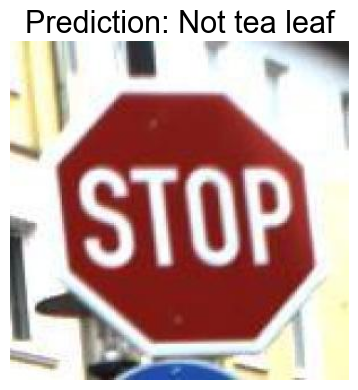

In [16]:
predict_and_plot(r"C:\Users\priya\project\filtre\test\Not tea leaf\brown (132).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


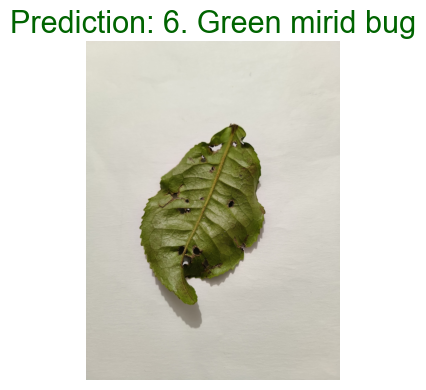

In [17]:
predict_and_plot(r"C:\Users\priya\project\TeaDs\test\6. Green mirid bug\green_mirid_bug_00560.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


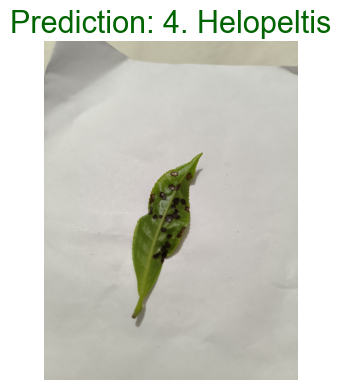

In [18]:
predict_and_plot(r"C:\Users\priya\project\TeaDs\test\4. Helopeltis\helopeltis_00150.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


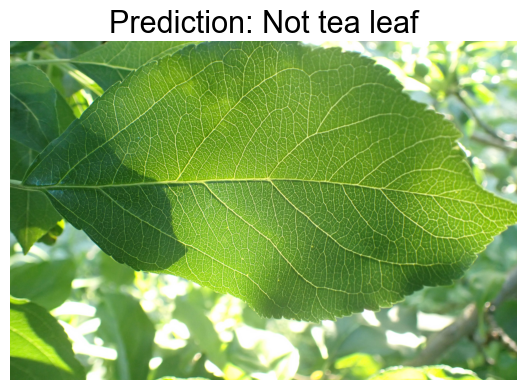

In [19]:
predict_and_plot(r"C:\Users\priya\project\filtre\test\Not tea leaf\8c2bb1e6bc87329c.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


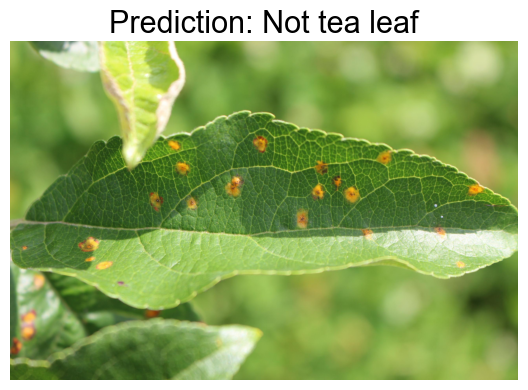

In [20]:
predict_and_plot(r"C:\Users\priya\project\filtre\test\Not tea leaf\87e3d0c12a7ba995.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


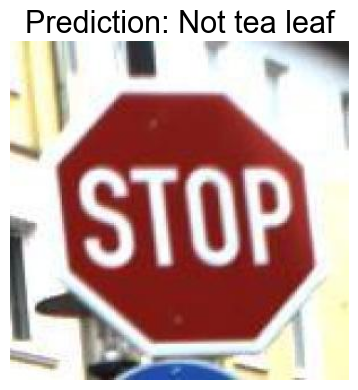

In [21]:
predict_and_plot(r"C:\Users\priya\project\filtre\test\Not tea leaf\brown (132).jpg" )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


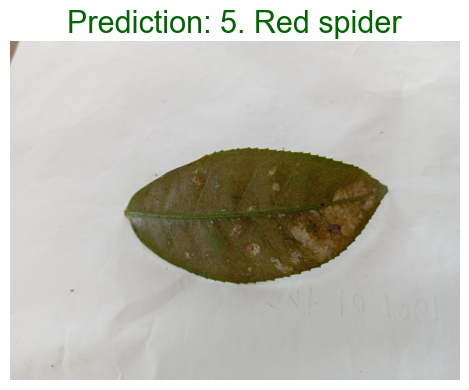

In [22]:
predict_and_plot(r"C:\Users\priya\project\TeaDs\test\5. Red spider\red_spider_00003.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


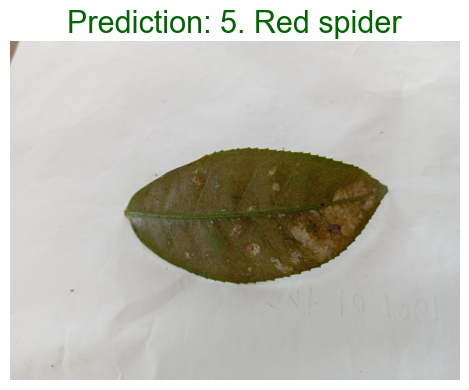

In [23]:
predict_and_plot(r"C:\Users\priya\project\TeaDs\test\5. Red spider\red_spider_00003.jpg")